DAY 15 — Mini Project: Student Performance Analysis

In [3]:
import pandas as pd
import numpy as np

# Student performance dataset
students = pd.DataFrame({
    "student_id": range(1, 16),
    "name": ["Amit", "Priya", "Rahul", "Sneha", "Karan",
             "Divya", "Rohan", "Pooja", "Arjun", "Neha",
             "Vikram", "Ananya", "Raj", "Meera", "Dev"],
    "age": [19, 20, 19, 21, 20, 19, 22, 20, 21, 19, 20, 21, 19, 20, 22],
    "city": ["Mumbai", "Delhi", "Mumbai", "Chennai", "Delhi",
             "Mumbai", "Pune", "Chennai", "Delhi", "Mumbai",
             "Pune", "Delhi", "Mumbai", "Chennai", "Pune"],
    "branch": ["AIML", "CSE", "AIML", "ECE", "CSE",
                "AIML", "CSE", "ECE", "AIML", "CSE",
                "ECE", "AIML", "CSE", "ECE", "AIML"]
})

marks = pd.DataFrame({
    "student_id": range(1, 16),
    "math":    [85, 92, 78, None, 88, 76, 95, 82, None, 90, 79, 88, 92, 75, 85],
    "science": [78, 88, 82, 91, 75, None, 89, 79, 85, 92, None, 84, 88, 81, 90],
    "english": [88, 79, 85, 87, 92, 83, 78, None, 88, 85, 82, 79, 85, 88, 92],
    "hindi":   [82, 85, 79, 88, 80, 85, 92, 84, 79, 88, 85, 92, 79, 85, 88]
})

attendance = pd.DataFrame({
    "student_id": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
    "attendance_pct": [92, 85, 78, 91, 65, 88, 95, 72, 80, 93, 69, 87, 91]
})

Part 1 — Data Preparation

In [13]:
def get_status(row):
    if row["average"]>=85 and row["attendance_pct"]>=90:
        return "Star"
    elif row["average"]>=75 and row["attendance_pct"]>=75:
        return "Good"
    elif row["attendance_pct"]<70:
        return "At risk"
    else:
        return "Average"

m1 = pd.merge(students, marks, on="student_id", how="outer")
m2 = pd.merge(students, attendance, on="student_id", how="outer")
merged_df = pd.merge(m1, m2, on="student_id", how="outer")
merged_df = merged_df.drop(labels=["name_y","age_y","branch_y","city_y"], axis=1)
merged_df = merged_df.rename(columns={"name_x": "name","age_x": "age","branch_x": "branch","city_x": "city"})
merged_df["attendance_pct"]=merged_df["attendance_pct"].fillna(merged_df["attendance_pct"].mean())
melted = merged_df.melt(
 id_vars="name",
 value_vars=["math","science","english","hindi"],
 var_name="subject",
 value_name="marks"   
)

merged_df = merged_df.fillna(melted["marks"].median())
merged_df["total"]= merged_df[["math","science","hindi","english"]].sum(axis=1)
merged_df["average"] = merged_df[["math","science","hindi","english"]].mean(axis=1)
merged_df["grade"] = merged_df["average"].apply(lambda x: "A" if x >= 90 else ("B" if x>=80 else ("C" if x >= 70 else "D")))

merged_df["status"] = merged_df.apply(get_status, axis=1)
merged_df["age group"] = pd.cut(
    merged_df["age"],
    bins=[18,19,21,22],
    labels=["Young","Mid","Senior"]
                                )
print(merged_df)
merged_df.to_csv("student_performance.csv")

    student_id    name  age     city branch  math  science  english  hindi  \
0            1    Amit   19   Mumbai   AIML  85.0     78.0     88.0     82   
1            2   Priya   20    Delhi    CSE  92.0     88.0     79.0     85   
2            3   Rahul   19   Mumbai   AIML  78.0     82.0     85.0     79   
3            4   Sneha   21  Chennai    ECE  85.0     91.0     87.0     88   
4            5   Karan   20    Delhi    CSE  88.0     75.0     92.0     80   
5            6   Divya   19   Mumbai   AIML  76.0     85.0     83.0     85   
6            7   Rohan   22     Pune    CSE  95.0     89.0     78.0     92   
7            8   Pooja   20  Chennai    ECE  82.0     79.0     85.0     84   
8            9   Arjun   21    Delhi   AIML  85.0     85.0     88.0     79   
9           10    Neha   19   Mumbai    CSE  90.0     92.0     85.0     88   
10          11  Vikram   20     Pune    ECE  79.0     85.0     82.0     85   
11          12  Ananya   21    Delhi   AIML  88.0     84.0     7

Part 2 — Analysis


In [ ]:
# total max marks student
print(merged_df.loc[merged_df["total"].idxmax(), "name"])

# highest avg mark city
print(merged_df.loc[merged_df["average"].idxmax(), "city"])

# most star student branch
star = merged_df[merged_df["status"]=="Star"].groupby("branch")["status"].value_counts()
print(star.idxmax())

# students are at risk
risk = merged_df[merged_df["status"]=="At risk"].groupby("branch", as_index=False)["status"].value_counts()
print(risk["count"].sum())

# average attendance per city
avg_attendance = merged_df.groupby("city", as_index=False)["attendance_pct"].mean()
print(avg_attendance)

# lowest average marks overall
avg_marks = melted.groupby("subject")["marks"].mean()
print(avg_marks.idxmin())



Neha
Mumbai
('CSE', 'Star')
2
      city  attendance_pct
0  Chennai       82.179487
1    Delhi       79.250000
2   Mumbai       88.400000
3     Pune       82.512821
hindi
             math   science   english     hindi     total   average
math     1.000000  0.381168 -0.279634  0.253280  0.744959  0.744959
science  0.381168  1.000000 -0.313831  0.491591  0.768491  0.768491
english -0.279634 -0.313831  1.000000 -0.474598 -0.095949 -0.095949
hindi    0.253280  0.491591 -0.474598  1.000000  0.597335  0.597335
total    0.744959  0.768491 -0.095949  0.597335  1.000000  1.000000
average  0.744959  0.768491 -0.095949  0.597335  1.000000  1.000000


Part 3 — Visualization Dashboard

C:\Users\katiy\AppData\Local\Temp\ipykernel_19688\2252333100.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(merged_df,x="name",y="total",palette="Set2",ax=axes[0])
C:\Users\katiy\AppData\Local\Temp\ipykernel_19688\2252333100.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(merged_df, x="branch", y="average", palette="Set3", ax=axes[2])
C:\Users\katiy\AppData\Local\Temp\ipykernel_19688\2252333100.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(merged_df, x="city", y="average", palette="Set1", ax=axes[3])


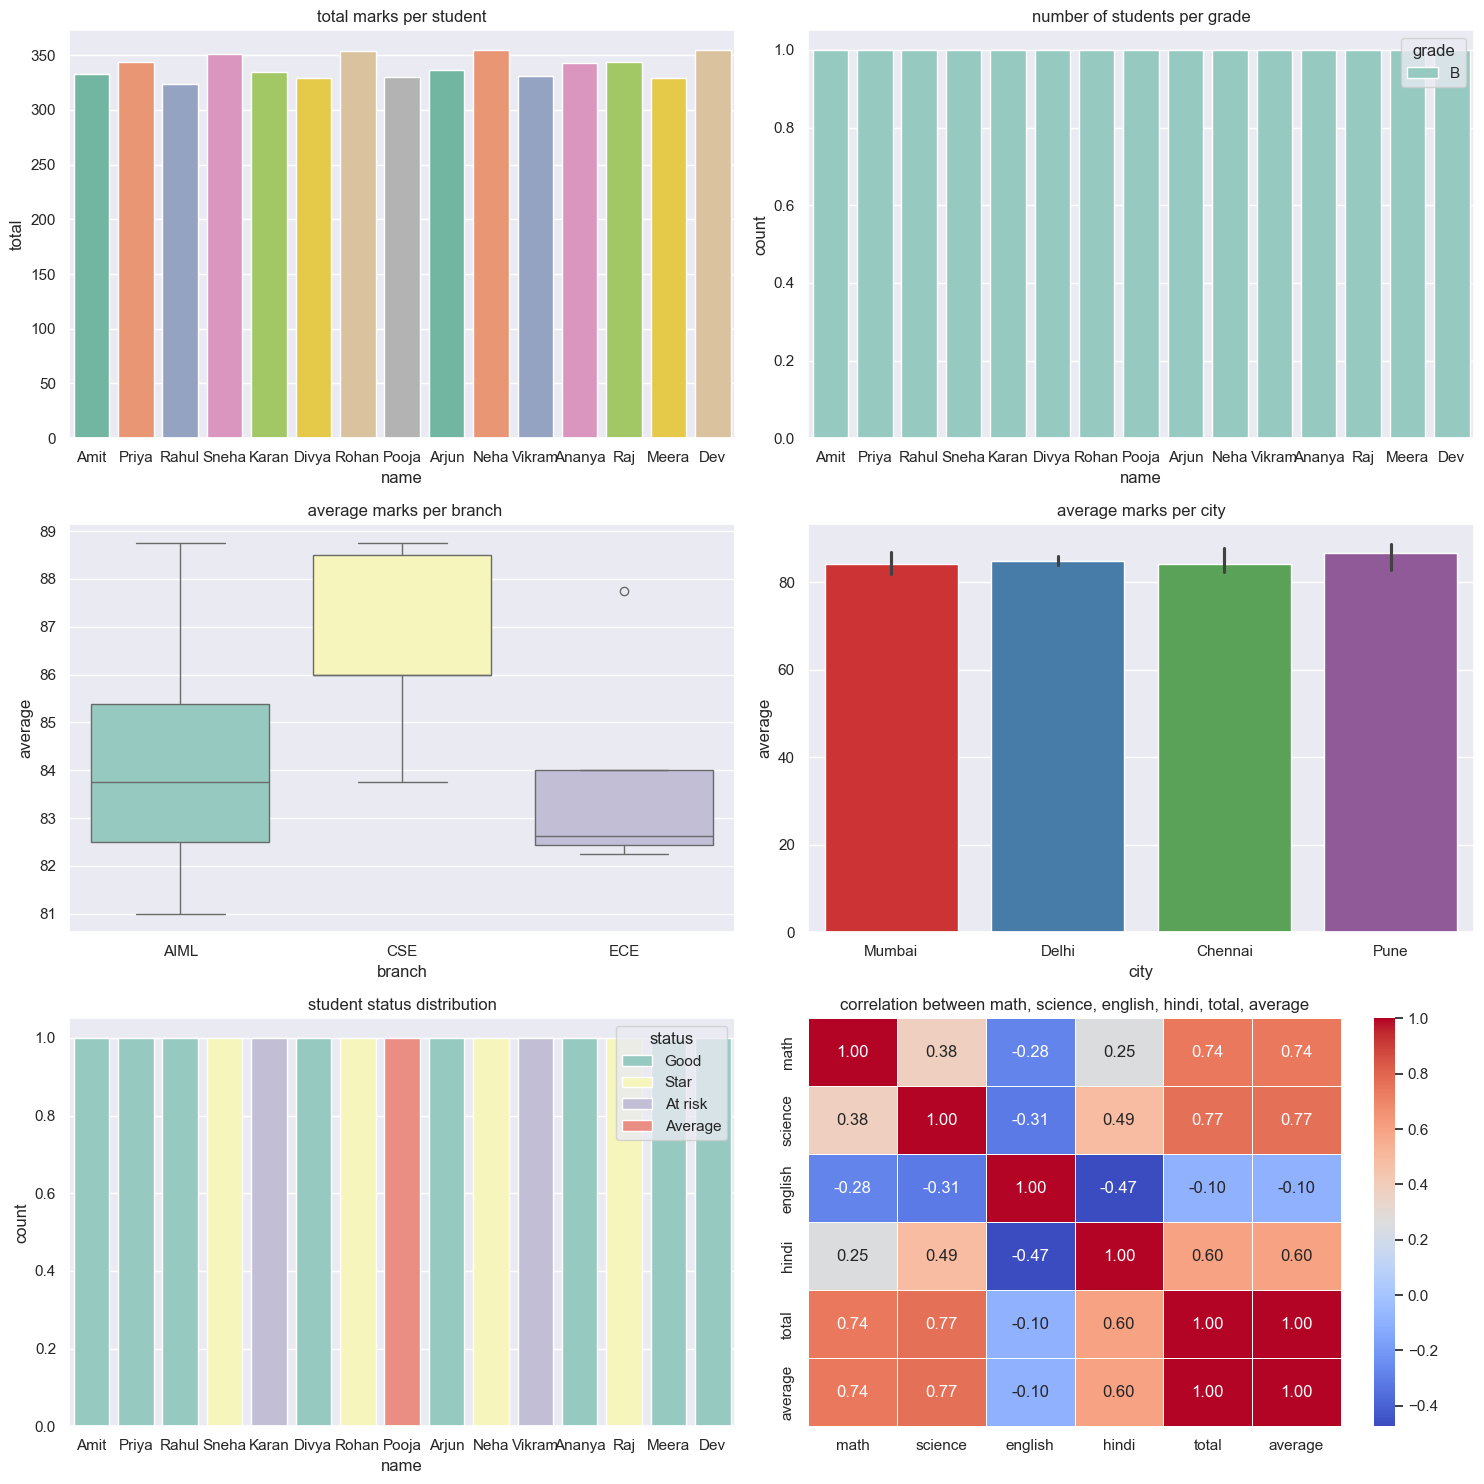

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")  
fig, axes = plt.subplots(3, 2, figsize=(15,15))
axes = axes.flatten()
sns.barplot(merged_df,x="name",y="total",palette="Set2",ax=axes[0])
axes[0].set_title("total marks per student")

sns.countplot(merged_df, x="name",hue="grade",palette="Set3",ax=axes[1])
axes[1].set_title("number of students per grade")

sns.boxplot(merged_df, x="branch", y="average", palette="Set3", ax=axes[2])
axes[2].set_title(" average marks per branch")

sns.barplot(merged_df, x="city", y="average", palette="Set1", ax=axes[3])
axes[3].set_title("average marks per city")

sns.countplot(merged_df, x="name", hue="status", palette="Set3", ax=axes[4])
axes[4].set_title("student status distribution")

sns.heatmap(
    merged_df[["math","science","english","hindi","total","average"]].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    ax=axes[5]
    )
axes[5].set_title("correlation between math, science, english, hindi, total, average")

plt.tight_layout()
plt.show()

Part 4 — Melt Challenge

      name  subject  marks
0     Amit     math   85.0
1    Priya     math   92.0
2    Rahul     math   78.0
3    Sneha     math    NaN
4    Karan     math   88.0
5    Divya     math   76.0
6    Rohan     math   95.0
7    Pooja     math   82.0
8    Arjun     math    NaN
9     Neha     math   90.0
10  Vikram     math   79.0
11  Ananya     math   88.0
12     Raj     math   92.0
13   Meera     math   75.0
14     Dev     math   85.0
15    Amit  science   78.0
16   Priya  science   88.0
17   Rahul  science   82.0
18   Sneha  science   91.0
19   Karan  science   75.0
20   Divya  science    NaN
21   Rohan  science   89.0
22   Pooja  science   79.0
23   Arjun  science   85.0
24    Neha  science   92.0
25  Vikram  science    NaN
26  Ananya  science   84.0
27     Raj  science   88.0
28   Meera  science   81.0
29     Dev  science   90.0
30    Amit  english   88.0
31   Priya  english   79.0
32   Rahul  english   85.0
33   Sneha  english   87.0
34   Karan  english   92.0
35   Divya  english   83.0
3

C:\Users\katiy\AppData\Local\Temp\ipykernel_19688\1676710931.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(melted, x="subject", y="marks", palette="Set2")


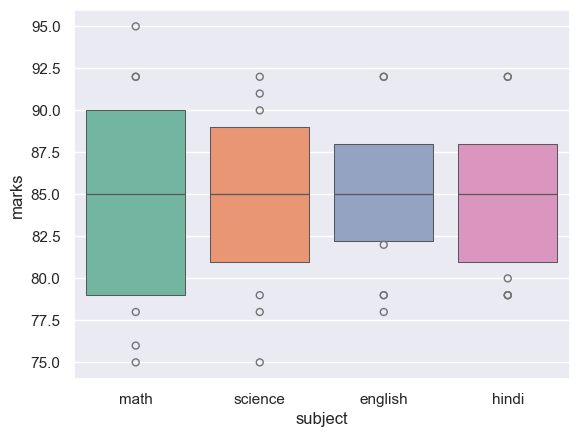

subject
math       6.557439
science    5.433750
english    4.497252
hindi      4.366539
Name: marks, dtype: float64


In [ ]:
print(melted)
sns.boxenplot(melted, x="subject", y="marks", palette="Set2")
plt.show()

highest_Std = melted.groupby("subject")["marks"].std()
print(highest_Std.sort_values(ascending=False))

# math has highest divation